In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.rcParams['figure.figsize'] = (12, 6)

# Load comments dataset
comments_path = Path('../data/raw/digikala-comments.csv')
df_comments = pd.read_csv(comments_path, nrows=400)

print(f"Total records: {len(df_comments):,}")
print(f"Total columns: {len(df_comments.columns)}")
print("\nColumn names and types:")
print(df_comments.dtypes)
print("\nFirst 5 records:")
df_comments.head(10)

Total records: 400
Total columns: 15

Column names and types:
id                         int64
title                     object
body                      object
created_at                object
rate                     float64
recommendation_status     object
is_buyer                    bool
product_id                 int64
advantages                object
disadvantages             object
likes                      int64
dislikes                   int64
seller_title              object
seller_code               object
true_to_size_rate         object
dtype: object

First 5 records:


,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN
5,53266157,خوبه,قبلا هم استفاده کردم اگه بلد باشین کار کردن با...,11 شهریور 1402,5.0,recommended,True,3305270,NaN,NaN,0,0,یانگوم,ERKSP,NaN
6,46206235,بدک نیست,خوبه,8 اسفند 1401,2.0,NaN,True,3480048,NaN,NaN,0,0,بازرگانی سوشیان,CKWY4,NaN
7,40597171,پد شستشوی براش,خیلی به کارتون میاد قیمتشم مناسبه,24 مهر 1401,5.0,recommended,True,3480048,"['جنسش خوبه\r', 'خوش رنگه\r', 'کاربردیه\r', 'ق...",['نداره '],1,0,بازرگانی سوشیان,CKWY4,NaN
8,46198656,لنز ناخون,دقیقا مطابق عکس بود,7 اسفند 1401,5.0,recommended,True,7626372,NaN,NaN,0,0,هستی نیل,E2C2D,NaN
9,46901811,خوب,برا حالت دادن با اسپری یا پودر عالیه,20 اسفند 1401,5.0,recommended,True,821812,NaN,NaN,0,0,پنی شاپ,CN6G3,NaN


In [7]:
# Basic statistics
print("="*50)
print("MISSING VALUES")
print("="*50)
print(df_comments.isnull().sum())
print(f"\nMissing percentage:")
print((df_comments.isnull().sum() / len(df_comments) * 100).round(2))

print("\n" + "="*50)
print("UNIQUE VALUES")
print("="*50)
print(f"Unique products: {df_comments['product_id'].nunique():,}")
print(f"Unique sellers: {df_comments['seller_code'].nunique():,}")
print(f"Rate distribution:\n{df_comments['rate'].value_counts().sort_index()}")
print(f"\nRecommendation status:\n{df_comments['recommendation_status'].value_counts()}")
print(f"\nIs buyer:\n{df_comments['is_buyer'].value_counts()}")

print("\n" + "="*50)
print("TEXT FIELDS LENGTH")
print("="*50)
df_comments['title_len'] = df_comments['title'].fillna('').str.len()
df_comments['body_len'] = df_comments['body'].fillna('').str.len()
print(f"Title length - Mean: {df_comments['title_len'].mean():.1f}, Max: {df_comments['title_len'].max()}")
print(f"Body length - Mean: {df_comments['body_len'].mean():.1f}, Max: {df_comments['body_len'].max()}")

print("\n" + "="*50)
print("SAMPLE COMMENT")
print("="*50)
sample = df_comments[df_comments['body'].notna()].iloc[0]
print(f"Title: {sample['title']}")
print(f"Body: {sample['body'][:200]}...")
print(f"Rate: {sample['rate']}")
print(f"Recommendation: {sample['recommendation_status']}")


MISSING VALUES
id                         0
title                    145
body                       0
created_at                 0
rate                       0
recommendation_status     27
is_buyer                   0
product_id                 0
advantages               328
disadvantages            347
likes                      0
dislikes                   0
seller_title               6
seller_code                6
true_to_size_rate        398
dtype: int64

Missing percentage:
id                        0.00
title                    36.25
body                      0.00
created_at                0.00
rate                      0.00
recommendation_status     6.75
is_buyer                  0.00
product_id                0.00
advantages               82.00
disadvantages            86.75
likes                     0.00
dislikes                  0.00
seller_title              1.50
seller_code               1.50
true_to_size_rate        99.50
dtype: float64

UNIQUE VALUES
Unique products: 363


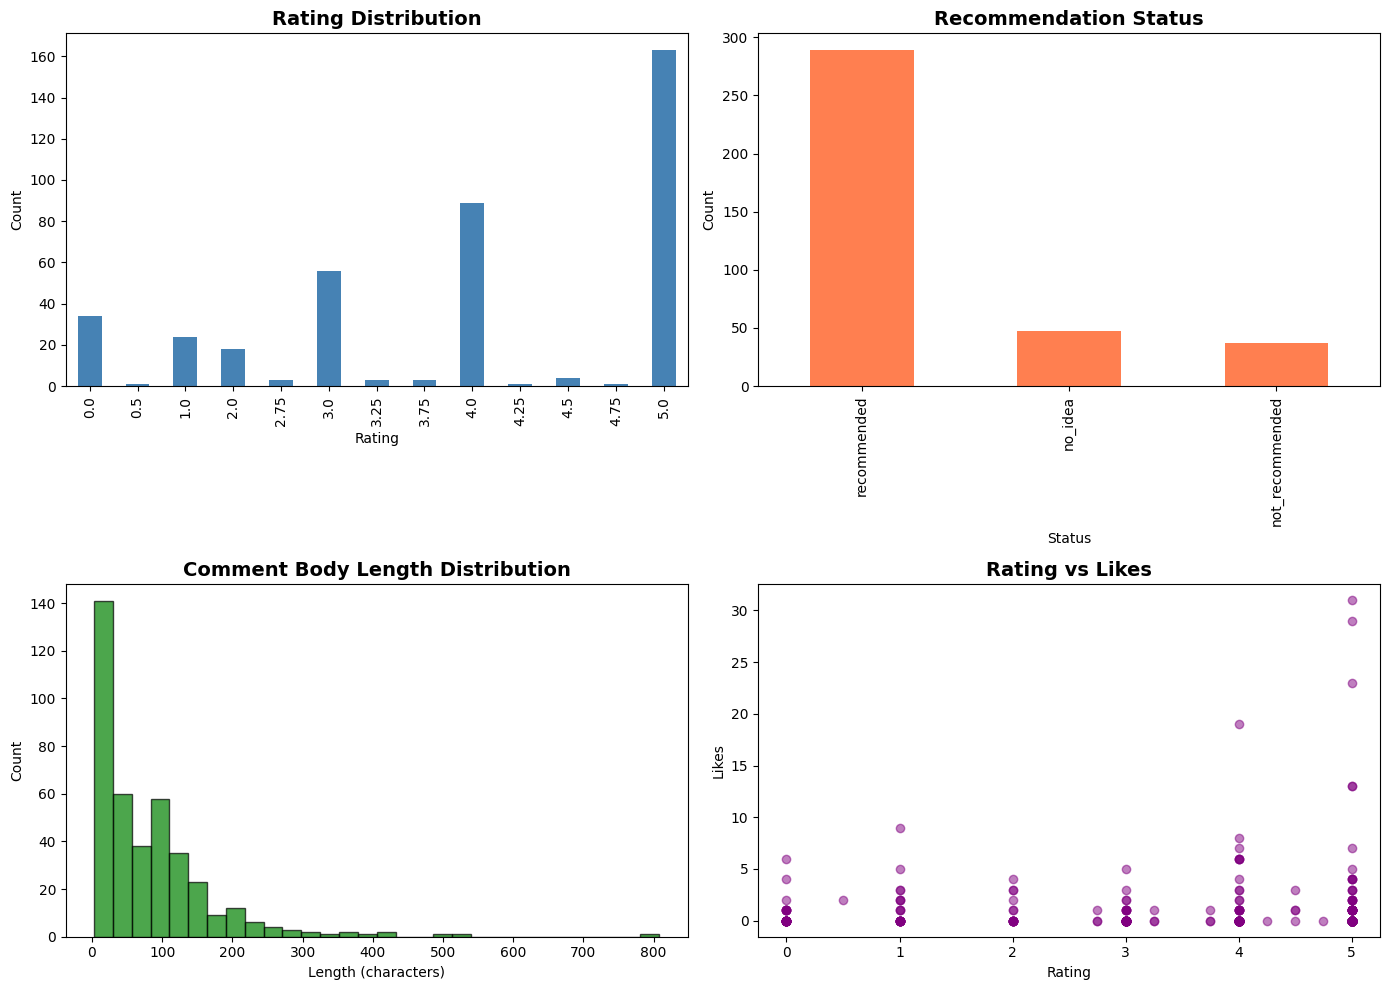


CORRELATION: Rate vs Likes
Correlation coefficient: 0.045


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Rate distribution
df_comments['rate'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# Recommendation status
df_comments['recommendation_status'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Recommendation Status', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Count')

# Text length distribution
axes[1,0].hist(df_comments['body_len'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Comment Body Length Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Length (characters)')
axes[1,0].set_ylabel('Count')

# Likes vs Rate
axes[1,1].scatter(df_comments['rate'], df_comments['likes'], alpha=0.5, color='purple')
axes[1,1].set_title('Rating vs Likes', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Rating')
axes[1,1].set_ylabel('Likes')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("CORRELATION: Rate vs Likes")
print("="*50)
print(f"Correlation coefficient: {df_comments['rate'].corr(df_comments['likes']):.3f}")
